In [14]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [15]:
import sys
print(sys.executable)

/Users/Redi/Documents/week9/portfolio-optimization/.venv/bin/python3.11


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

df = pd.read_csv("../data/processed/clean_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])
df = df.dropna(subset=["Daily_Return"])

In [23]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_stock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"])

In [24]:
tsla = df[df["Ticker"] == "TSLA"][["Date", "Daily_Return"]].copy()
tsla.set_index("Date", inplace=True)

values = tsla["Daily_Return"].values.reshape(-1, 1)

print(values.shape)

(2887, 1)


In [25]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

CREATE SEQUENCES

In [26]:
def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)

lookback = 30
X, y = create_sequences(scaled, lookback)

print(X.shape, y.shape)

(2857, 30, 1) (2857, 1)


TRAIN / TEST SPLIT

In [27]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)

(2285, 30, 1) (572, 30, 1)


BUILD LSTM MODEL

In [28]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(lookback, 1)))
model.add(LSTM(50))

model.add(Dense(1))

model.compile(optimizer="adam", loss="mse")

model.summary()

/Users/Redi/Documents/week9/portfolio-optimization/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0179 - val_loss: 0.0080
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0068 - val_loss: 0.0079
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0068 - val_loss: 0.0080
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0071 - val_loss: 0.0079
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0068 - val_loss: 0.0080
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0068 - val_loss: 0.0080
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0069 - val_loss: 0.0092
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0068 - val_loss: 0.0080
Epoch 9/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0069 - val_loss: 0.0079
Epoch 10/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0069 - val_loss: 0.0081


In [30]:
pred = model.predict(X_test)

# invert scaling
pred_inv = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


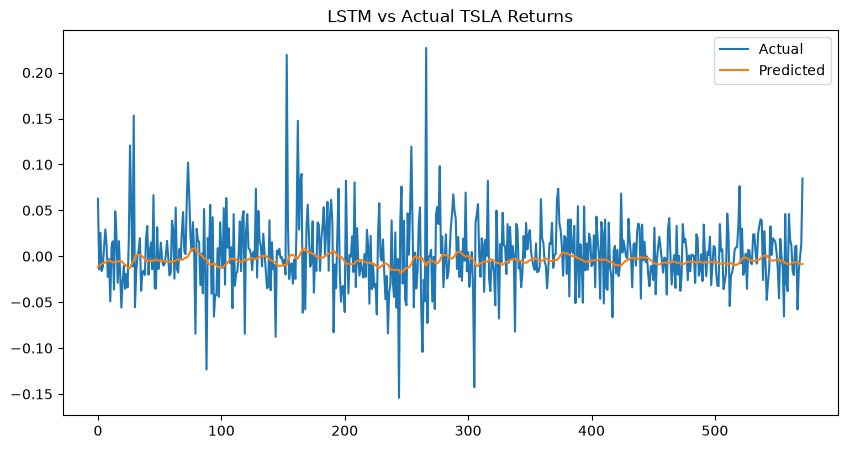

In [31]:
plt.figure(figsize=(10,5))

plt.plot(y_test_inv, label="Actual")
plt.plot(pred_inv, label="Predicted")

plt.title("LSTM vs Actual TSLA Returns")
plt.legend()
plt.show()

In [32]:
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
print("LSTM RMSE:", rmse)

LSTM RMSE: 0.03928937253424791


In [34]:
y_pred = scaler.inverse_transform(pred)

In [35]:
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [36]:
y_pred = np.array(y_pred).flatten()
y_test_actual = np.array(y_test_actual).flatten()

In [37]:
import os
import numpy as np

os.makedirs("../outputs", exist_ok=True)

np.save("../outputs/lstm_predictions.npy", y_pred)
np.save("../outputs/lstm_test.npy", y_test_actual)